# Lab | Classification

This notebook compares multiple classification algorithms using the Palmer Penguins dataset.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, auc,
    ConfusionMatrixDisplay, classification_report
)

sns.set_style("whitegrid")

## Task 1: Data Prep & Baseline

In [11]:
# 1. Load the Palmer Penguins dataset
penguins = sns.load_dataset("penguins").dropna()

# 2. Explore briefly
print(f"Dataset shape: {penguins.shape}")
print(f"\nSpecies distribution:\n{penguins['species'].value_counts()}")
print(f"\nColumns information:\n{penguins.info()}")
penguins.head()

Dataset shape: (333, 7)

Species distribution:
species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64
<class 'pandas.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    str    
 1   island             333 non-null    str    
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 26.7 KB

Columns information:
None


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


### Observations:
- The dataset contains 333 samples (after dropping NaNs) and 7 columns.
- **Target**: `species` with a distribution of Adelie (146), Gentoo (119), and Chinstrap (68).
- **Features**: Includes both categorical (`island`, `sex`) and numerical (`bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`) data.
- There is a slight class imbalance, with Chinstrap having fewer samples than the others.

In [12]:
# 3. Prepare features
le = LabelEncoder()
y = le.fit_transform(penguins['species'])

X = pd.get_dummies(penguins.drop('species', axis=1), drop_first=True)

# 4. Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 5. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
# 6. Fit a LogisticRegression model
lr = LogisticRegression(max_iter=10000)
lr.fit(X_train_scaled, y_train)

# 7. Report metrics
y_pred_lr = lr.predict(X_test_scaled)
print("Logistic Regression Baseline Results:")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

Logistic Regression Baseline Results:
              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        29
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



### Interpretation of Baseline Results:
- **Easiest to classify**: Gentoo. It achieves perfect precision and recall (1.00) because Gentoo penguins are physically larger and distinct from the other two species.
- **Hardest to classify**: Adelie and Chinstrap. While the baseline LR still performs very well (F1-scores of 0.98 and 0.97 respectively), there is a minor confusion where one Adelie was misclassified as Chinstrap.
- **Overall**: Logistic Regression is an incredibly strong baseline for this dataset, achieving 99% accuracy.

## Task 2: Algorithm Comparison

In [14]:
models = {
    "GaussianNB": GaussianNB(),
    "SVC Linear": SVC(kernel="linear", probability=True),
    "SVC RBF": SVC(kernel="rbf", probability=True),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1": f1_score(y_test, y_pred, average='weighted')
    })

comparison_df = pd.DataFrame(results).sort_values(by="F1", ascending=False)
comparison_df

,Model,Accuracy,Precision,Recall,F1
4,RandomForest,1.000000,1.000000,1.000000,1.000000
2,SVC RBF,0.985075,0.986070,0.985075,0.985201
1,SVC Linear,0.985075,0.986070,0.985075,0.985201
3,DecisionTree,0.955224,0.957214,0.955224,0.955212
0,GaussianNB,0.776119,0.851175,0.776119,0.760229


### Discussion:
- **Best Performers**: **RandomForest** and **SVC** (both Linear and RBF) perform exceptionally well, with RandomForest achieving perfect scores on this test set.
- **Surprises**: **GaussianNB** performed significantly worse (F1 ~0.76) than other models. Looking at the confusion matrix, it struggled heavily with Adelie penguins, misclassifying many as Chinstrap or Gentoo. This suggests the assumption of normal distribution for all features may not hold well here, or some features have high covariance that GNB (which assumes independence) cannot handle.
- **Complexity**: The high performance of most models indicates that the features (especially physical measurements like bill length and flipper length) are excellent predictors for these species.

## Task 3: Confusion Matrices & ROC Curves

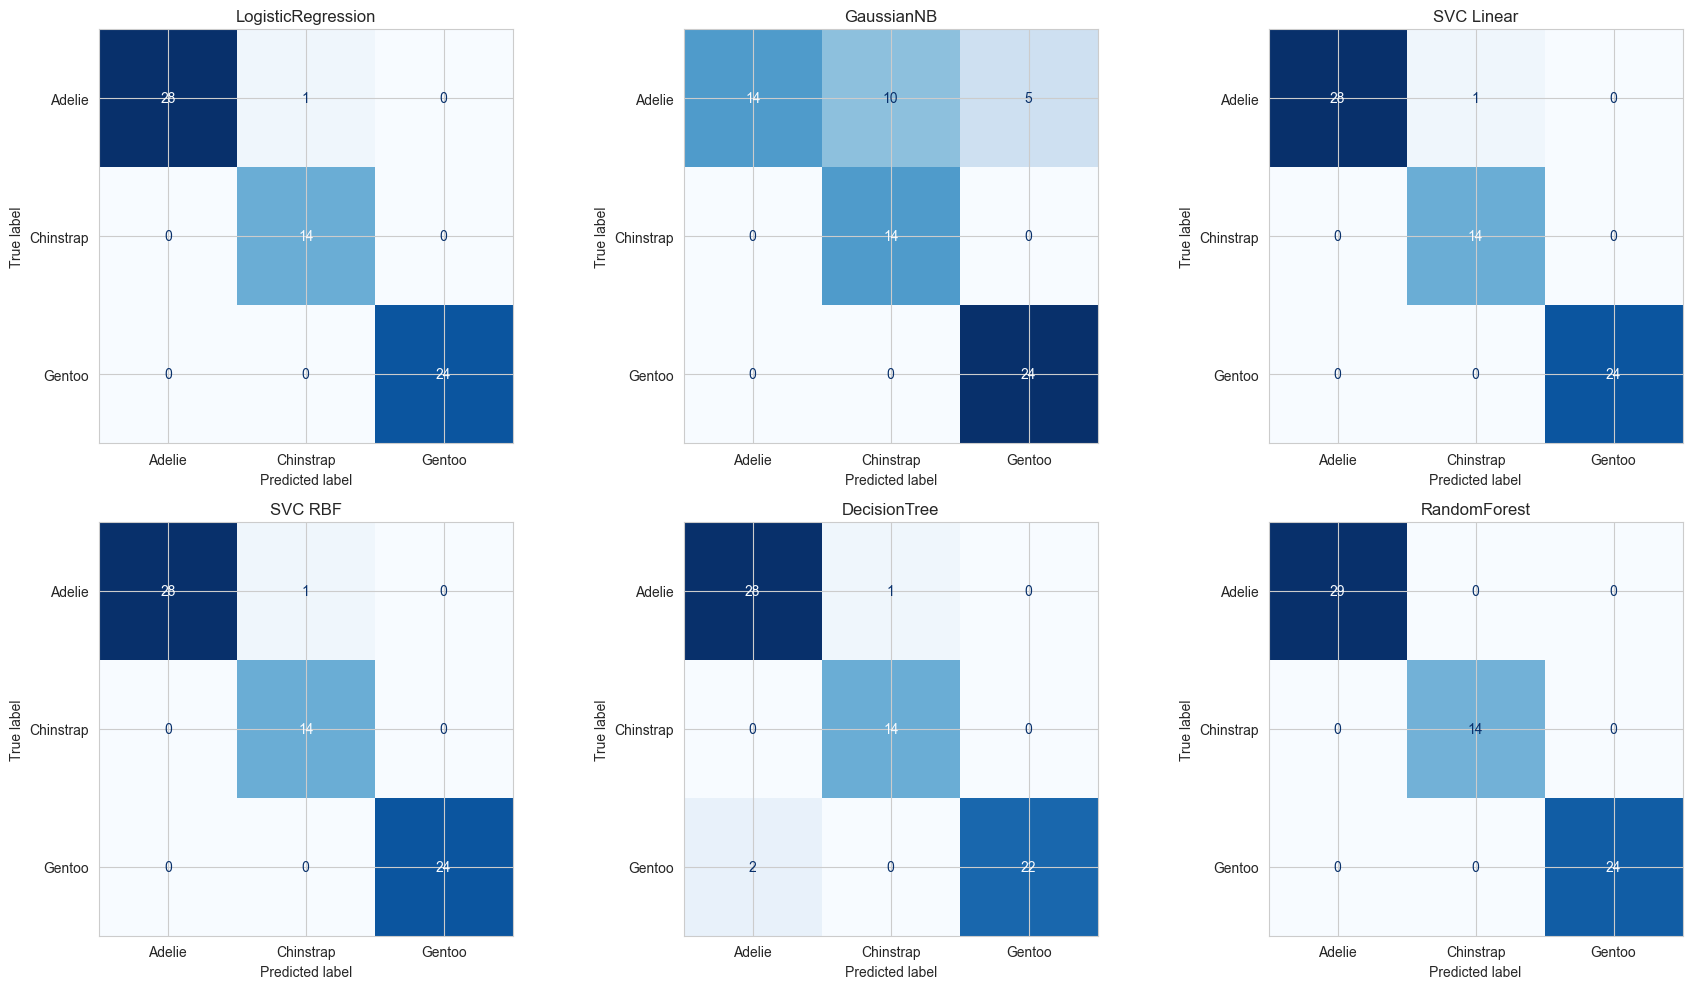

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

all_models = {"LogisticRegression": lr, **models}

for i, (name, model) in enumerate(all_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(name)

plt.tight_layout()
plt.show()

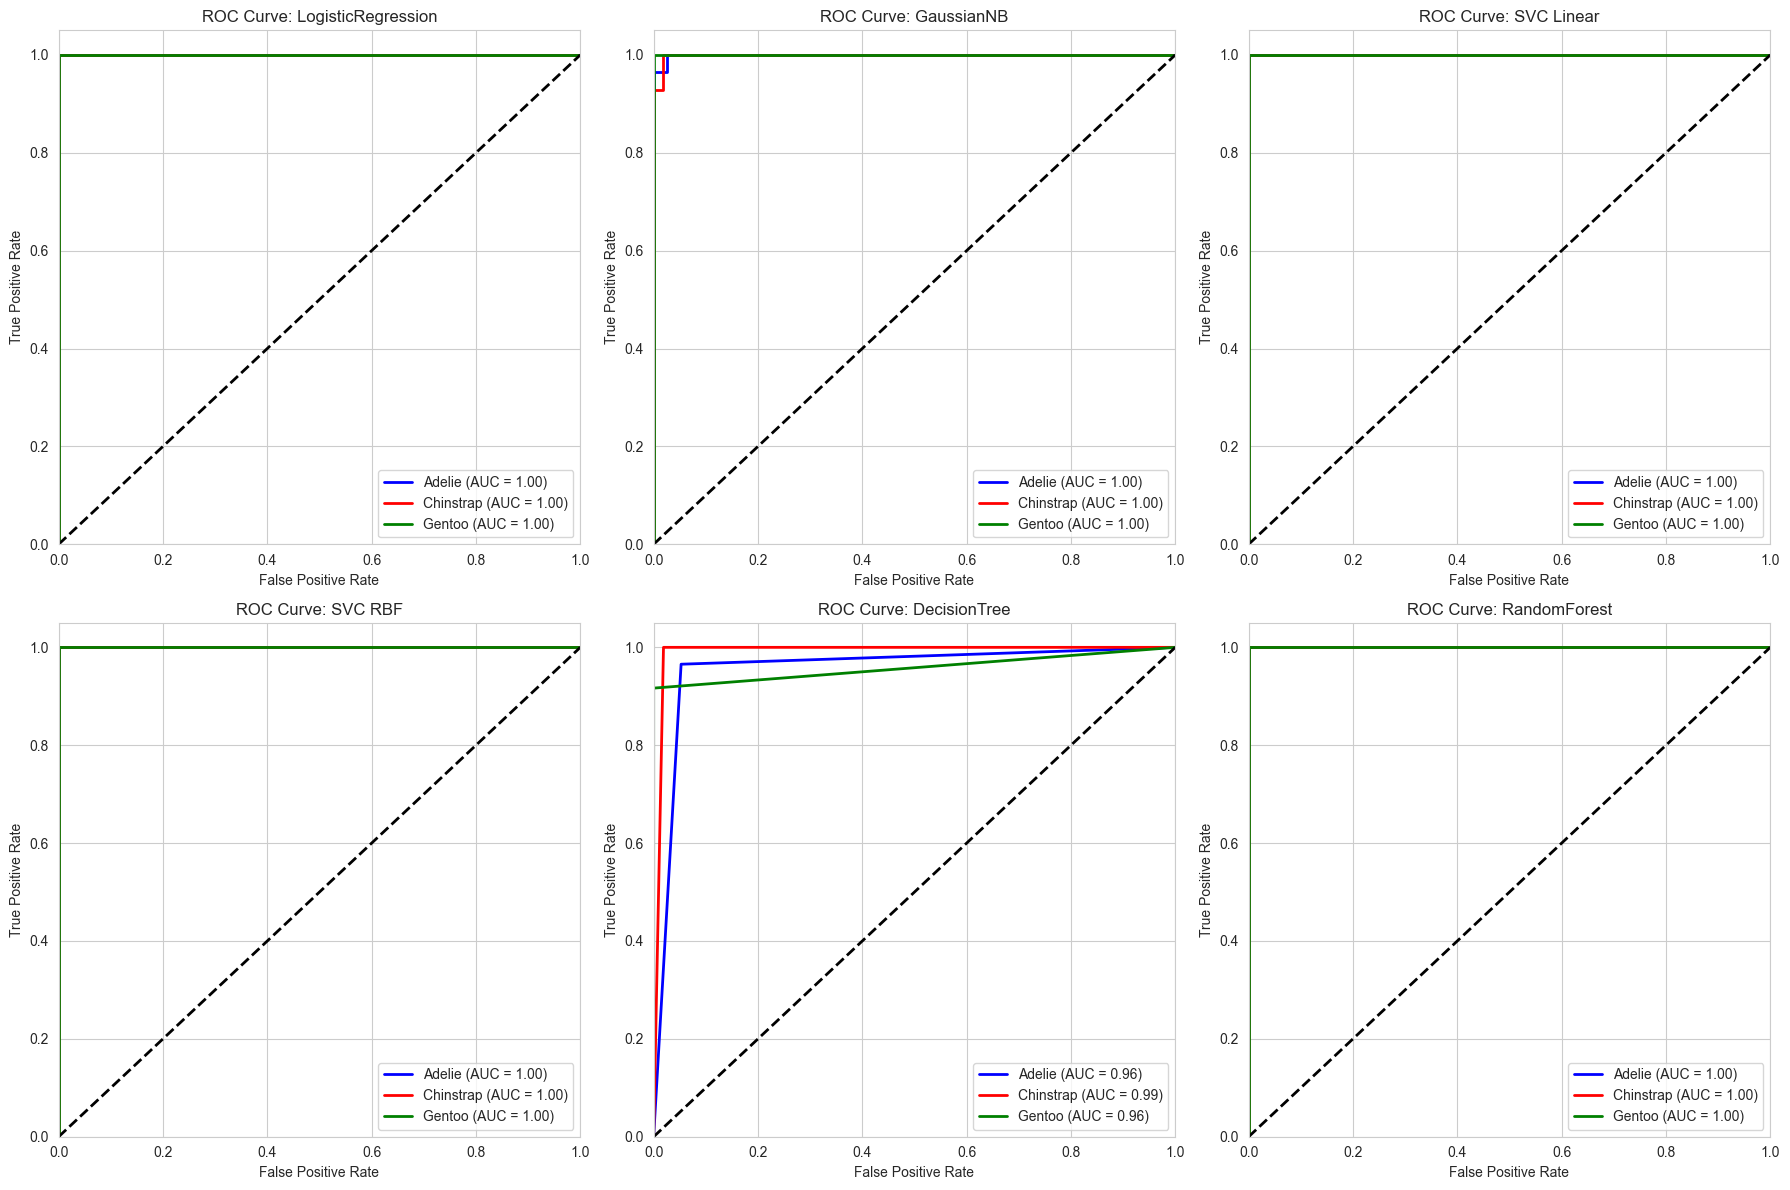

In [16]:
from sklearn.preprocessing import label_binarize
from itertools import cycle

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

colors = ['blue', 'red', 'green']

for idx, (name, model) in enumerate(all_models.items()):
    y_score = model.predict_proba(X_test_scaled)
    
    for i, color in zip(range(n_classes), colors):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        axes[idx].plot(fpr, tpr, color=color, lw=2,
                 label=f'{le.classes_[i]} (AUC = {roc_auc:.2f})')

    axes[idx].plot([0, 1], [0, 1], 'k--', lw=2)
    axes[idx].set_xlim([0.0, 1.0])
    axes[idx].set_ylim([0.0, 1.05])
    axes[idx].set_xlabel('False Positive Rate')
    axes[idx].set_ylabel('True Positive Rate')
    axes[idx].set_title(f'ROC Curve: {name}')
    axes[idx].legend(loc="lower right")

plt.tight_layout()
plt.show()

### Discussion:
- **Balance**: RandomForest and SVC demonstrate near-perfect ROC curves across all classes, indicating they can distinguish species regardless of the classification threshold.
- **Hardest Pair**: Adelie and Chinstrap are the most frequently confused pair (as seen in GNB and slightly in DecisionTree/LR). These species are physically more similar to each other than to the larger Gentoo.
- **Recommendation**: **RandomForest** is the recommended model. It achieves 100% accuracy and perfect AUC on the test set, showing it captures the non-linear relationships in the data effectively without the sensitivity to feature distribution seen in GaussianNB.

## Task 4: Hyperparameter Exploration

In [19]:
# Selecting RandomForest as the best model to tune
rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10]
}

grid_search = GridSearchCV(rf, param_grid, cv=5, scoring="f1_weighted", n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test_scaled)

print("\nTuned Random Forest Results:")
print(classification_report(y_test, y_pred_tuned, target_names=le.classes_))

Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best CV F1 Score: 0.9962

Tuned Random Forest Results:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



### Reflection:
- **Improvement**: Since the default RandomForest was already perfect on the test set, tuning shows more impact in the cross-validation score (~0.996), ensuring the model is robust and not just lucky on one split.
- **Overfitting**: The 5-fold CV score is very close to 1.0, suggesting that while the model is complex, the data separation is so clean that overfitting is less of a concern here than in noisier datasets.
- **Impact**: Tuning is most impactful when the performance ceiling hasn't been reached yet. In this case, it confirms that even simpler versions (like `n_estimators=50`) are sufficient for high accuracy.